In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

DATA COLLECTION


In [3]:
df=pd.read_csv('./warmupdata/threat_dataset.csv')
df.head()

,ZoneID,Temp,NoiseLevel,CrowdDensity,IncidentReports,CCTVAlerts,InternetTraffic,ThreatLevel
0,Z172,35,71,390,6,1,834,High
1,Z209,34,87,357,3,0,712,High
2,Z036,26,71,268,2,0,419,Low
3,Z008,31,81,160,2,0,787,Low
4,Z012,28,64,212,3,2,783,Low


In [4]:
df.shape

(1500, 8)

In [5]:
df.describe()

,Temp,NoiseLevel,CrowdDensity,IncidentReports,CCTVAlerts,InternetTraffic
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000
mean,31.408667,72.952667,311.044000,2.66600,1.215333,658.259333
std,3.291334,12.270730,127.388217,1.58791,1.265187,256.381200
min,22.000000,42.000000,57.000000,0.00000,0.000000,109.000000
25%,29.000000,63.000000,211.000000,1.00000,0.000000,424.000000
50%,32.000000,73.000000,332.000000,3.00000,1.000000,752.000000
75%,34.000000,85.000000,422.000000,4.00000,2.000000,868.250000
max,40.000000,96.000000,499.000000,7.00000,5.000000,996.000000


In [6]:
df.columns

Index(['ZoneID', 'Temp', 'NoiseLevel', 'CrowdDensity', 'IncidentReports',
       'CCTVAlerts', 'InternetTraffic', 'ThreatLevel'],
      dtype='object')

DATA PREPROCESSING

In [7]:
df.isnull().sum()

ZoneID             0
Temp               0
NoiseLevel         0
CrowdDensity       0
IncidentReports    0
CCTVAlerts         0
InternetTraffic    0
ThreatLevel        0
dtype: int64

In [8]:
df['ThreatLevel'].value_counts()

ThreatLevel
High      500
Low       500
Medium    500
Name: count, dtype: int64

In [9]:
df['ThreatLevel'] = df['ThreatLevel'].map({'Low': 0, 'Medium': 1, 'High':2})
df.head()

,ZoneID,Temp,NoiseLevel,CrowdDensity,IncidentReports,CCTVAlerts,InternetTraffic,ThreatLevel
0,Z172,35,71,390,6,1,834,2
1,Z209,34,87,357,3,0,712,2
2,Z036,26,71,268,2,0,419,0
3,Z008,31,81,160,2,0,787,0
4,Z012,28,64,212,3,2,783,0


DATA VISUALISATION

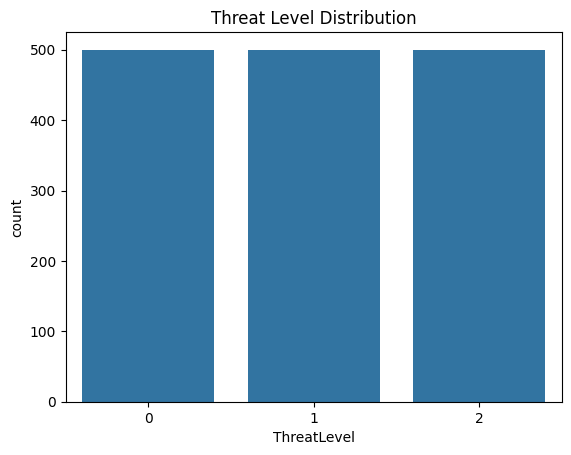

In [10]:
sns.countplot(x='ThreatLevel', data=df)
plt.title("Threat Level Distribution")
plt.show()

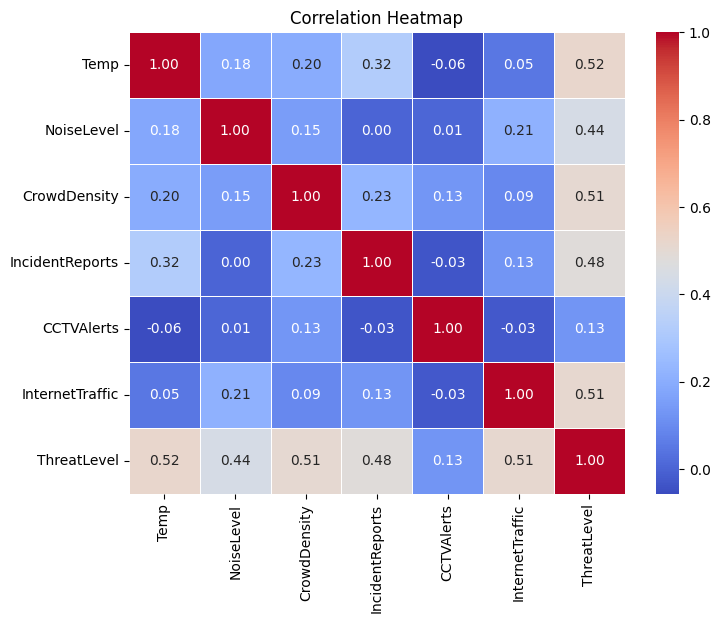

In [11]:
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

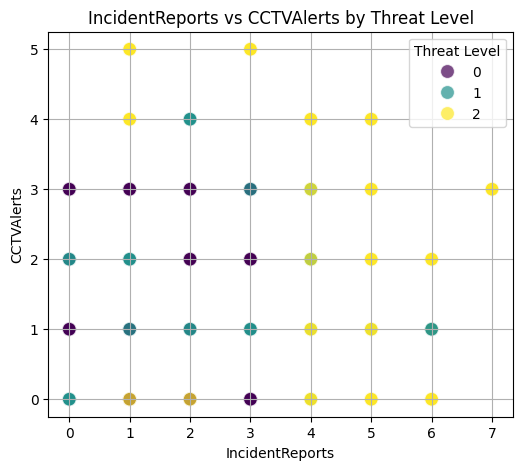

In [12]:
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x='IncidentReports',
    y='CCTVAlerts',
    hue='ThreatLevel',
    data=df,
    palette='viridis',
    alpha=0.7,
    s=100
)

plt.title('IncidentReports vs CCTVAlerts by Threat Level')
plt.xlabel('IncidentReports')
plt.ylabel('CCTVAlerts')
plt.legend(title='Threat Level')
plt.grid(True)
plt.show()

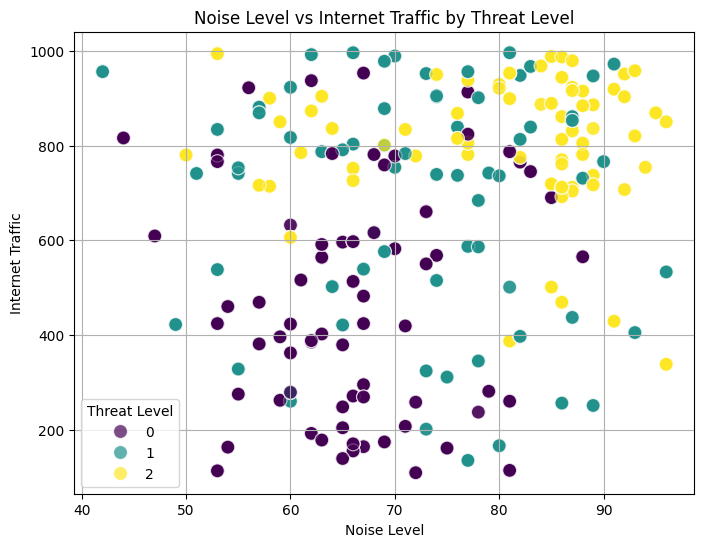

In [13]:

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='NoiseLevel',
    y='InternetTraffic',
    hue='ThreatLevel',
    data=df,
    palette='viridis',
    alpha=0.7,
    s=100
)

plt.title('Noise Level vs Internet Traffic by Threat Level')
plt.xlabel('Noise Level')
plt.ylabel('Internet Traffic')
plt.legend(title='Threat Level')
plt.grid(True)
plt.show()

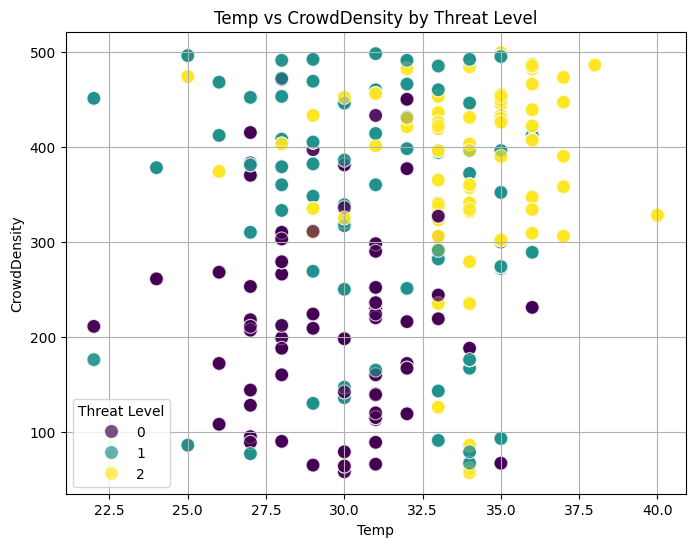

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Temp',
    y='CrowdDensity',
    hue='ThreatLevel',
    data=df,
    palette='viridis',
    alpha=0.7,
    s=100
)

plt.title('Temp vs CrowdDensity by Threat Level')
plt.xlabel('Temp')
plt.ylabel('CrowdDensity')
plt.legend(title='Threat Level')
plt.grid(True)
plt.show()

MODEL BUILDING


In [15]:
x=df.drop(['ZoneID','ThreatLevel'], axis=1)
y=df['ThreatLevel']

In [16]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [19]:
model = keras.Sequential([
    keras.layers.Dense(64, input_shape=(x.shape[1],), activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(3, activation='softmax')  
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=163, batch_size=16, validation_split=0.2)

Epoch 1/163
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4570 - loss: 1.0257 - val_accuracy: 0.7417 - val_loss: 0.7145
Epoch 2/163
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7318 - loss: 0.6845 - val_accuracy: 0.8500 - val_loss: 0.4751
Epoch 3/163
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8474 - loss: 0.4753 - val_accuracy: 0.8833 - val_loss: 0.3549
Epoch 4/163
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8400 - loss: 0.4117 - val_accuracy: 0.9042 - val_loss: 0.3054
Epoch 5/163
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8538 - loss: 0.3613 - val_accuracy: 0.9125 - val_loss: 0.2685
Epoch 6/163
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9062 - loss: 0.3056 - val_accuracy: 0.9083 - val_loss: 0.2461
Epoch 7/163
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8867 - loss: 0.2842 - val_accuracy: 0.9250 - val_loss: 0.2311
Epoch 8/163
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9091 - loss: 0.2599 - val_accuracy: 0.9292 - v

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopper = EarlyStopping(
    monitor='val_loss',    
    patience=10,            
    restore_best_weights=True  
)

model = keras.Sequential([
    keras.layers.Dense(64, input_shape=(x.shape[1],), activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    x_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopper] 
)

Epoch 1/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5272 - loss: 0.9708 - val_accuracy: 0.8500 - val_loss: 0.6581
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7714 - loss: 0.6358 - val_accuracy: 0.9208 - val_loss: 0.4318
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8391 - loss: 0.4577 - val_accuracy: 0.8958 - val_loss: 0.3267
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8575 - loss: 0.3678 - val_accuracy: 0.9042 - val_loss: 0.2783
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8572 - loss: 0.3513 - val_accuracy: 0.8958 - val_loss: 0.2554
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9024 - loss: 0.2749 - val_accuracy: 0.9042 - val_loss: 0.2319
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9037 - loss: 0.2605 - val_accuracy: 0.9083 - val_loss: 0.2169
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8975 - loss: 0.2604 - val_accuracy: 0.9125 - 

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report


df=pd.read_csv('./warmupdata/threat_dataset.csv')

feature_cols = ["Temp", "NoiseLevel", "CrowdDensity", "IncidentReports", "CCTVAlerts", "InternetTraffic"]
target_col = "ThreatLevel"

X = df[feature_cols]
y = df[target_col]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


models = {
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.1,
        validation_fraction=0.1,
        n_iter_no_change=10,
        tol=1e-4,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(random_state=42),  
    "Logistic Regression": LogisticRegression(
        max_iter=1000  
    ),
    "SVM (SGD-based)": SGDClassifier(
        loss='hinge',  
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        tol=1e-4,
        random_state=42
    ),
    "KNN": KNeighborsClassifier()  
}

best_model = None
best_model_name = ""
best_accuracy = 0.0

print("\n📊 Model Evaluation Results")
print("===========================================\n")


for name, model in models.items():
    print(f"🔍 Evaluating: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = model.score(X_test, y_test)
    
    print(f"✅ Accuracy: {accuracy:.4f}")
    print("📄 Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50 + "\n")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        best_model_name = name


print("\n🏁 Final Summary")
print("===========================================")
print(f"🏆 Best Performing Model: {best_model_name}")
print(f"🎯 Best Accuracy Achieved: {best_accuracy:.4f}")
print("===========================================\n")


📊 Model Evaluation Results

🔍 Evaluating: Gradient Boosting
✅ Accuracy: 0.7381
📄 Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.86      0.80        14
         Low       0.83      0.71      0.77        14
      Medium       0.64      0.64      0.64        14

    accuracy                           0.74        42
   macro avg       0.74      0.74      0.74        42
weighted avg       0.74      0.74      0.74        42

--------------------------------------------------

🔍 Evaluating: Random Forest
✅ Accuracy: 0.8095
📄 Classification Report:
              precision    recall  f1-score   support

        High       0.87      0.93      0.90        14
         Low       0.85      0.79      0.81        14
      Medium       0.71      0.71      0.71        14

    accuracy                           0.81        42
   macro avg       0.81      0.81      0.81        42
weighted avg       0.81      0.81      0.81        42

---------

In [24]:
import numpy as np
from sklearn.preprocessing import StandardScaler

feature_names = ["Temperature", "Noise Level", "Crowd Density", "Incident Report", "CCTV Alert", "Internet Traffic"]


class_labels = {0: "Safe", 1: "Moderate", 2: "Critical"}

user_input = []

for feature in feature_names:
    val = float(input(f"Enter value for {feature}: "))
    user_input.append(val)

user_input = np.array(user_input).reshape(1, -1)

user_input_scaled = scaler.transform(user_input)

prediction = model.predict(user_input_scaled)

predicted_class = np.argmax(prediction)

predicted_label = class_labels[predicted_class]

print(f"\n🛡️  Predicted Situation: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

🛡️  Predicted Situation: Critical


d:\Deep Learning\tf-env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

with open('threat_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)


with open('threat_model.pkl', 'wb') as file:
    pickle.dump(model, file)
